In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

##### Data Exploration and Understanding

In [44]:
file_path ='/Users/shubhangimore/Stock_Price_Prediction/Dataset/portfolio_data.csv'
data= pd.read_csv(file_path)
data

,Date,AMZN,DPZ,BTC,NFLX
0,5/1/2013,248.229996,51.190983,106.250000,30.415714
1,5/2/2013,252.550003,51.987320,98.099998,30.641428
2,5/3/2013,258.049988,52.446388,112.900002,30.492857
3,5/6/2013,255.720001,53.205257,109.599998,30.098572
4,5/7/2013,257.730011,54.151505,113.199997,29.464285
...,...,...,...,...,...
1515,5/8/2019,1917.770020,283.149994,6171.959961,364.369995
1516,5/9/2019,1899.869995,282.160004,6358.290039,362.750000
1517,5/10/2019,1889.979980,278.369995,7191.359863,361.040009
1518,5/13/2019,1822.680054,273.880005,7980.129883,345.260010


In [45]:
data.shape

(1520, 5)

In [46]:
data.dtypes

Date     object
AMZN    float64
DPZ     float64
BTC     float64
NFLX    float64
dtype: object

In [47]:
data.describe

<bound method NDFrame.describe of            Date         AMZN         DPZ          BTC        NFLX
0      5/1/2013   248.229996   51.190983   106.250000   30.415714
1      5/2/2013   252.550003   51.987320    98.099998   30.641428
2      5/3/2013   258.049988   52.446388   112.900002   30.492857
3      5/6/2013   255.720001   53.205257   109.599998   30.098572
4      5/7/2013   257.730011   54.151505   113.199997   29.464285
...         ...          ...         ...          ...         ...
1515   5/8/2019  1917.770020  283.149994  6171.959961  364.369995
1516   5/9/2019  1899.869995  282.160004  6358.290039  362.750000
1517  5/10/2019  1889.979980  278.369995  7191.359863  361.040009
1518  5/13/2019  1822.680054  273.880005  7980.129883  345.260010
1519  5/14/2019  1840.119995  272.859985  8183.830078  345.609985

[1520 rows x 5 columns]>

In [48]:
data.isnull()

,Date,AMZN,DPZ,BTC,NFLX
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1515,False,False,False,False,False
1516,False,False,False,False,False
1517,False,False,False,False,False
1518,False,False,False,False,False


In [49]:
data.head()

,Date,AMZN,DPZ,BTC,NFLX
0,5/1/2013,248.229996,51.190983,106.250000,30.415714
1,5/2/2013,252.550003,51.987320,98.099998,30.641428
2,5/3/2013,258.049988,52.446388,112.900002,30.492857
3,5/6/2013,255.720001,53.205257,109.599998,30.098572
4,5/7/2013,257.730011,54.151505,113.199997,29.464285


In [50]:
data.tail()

,Date,AMZN,DPZ,BTC,NFLX
1515,5/8/2019,1917.770020,283.149994,6171.959961,364.369995
1516,5/9/2019,1899.869995,282.160004,6358.290039,362.750000
1517,5/10/2019,1889.979980,278.369995,7191.359863,361.040009
1518,5/13/2019,1822.680054,273.880005,7980.129883,345.260010
1519,5/14/2019,1840.119995,272.859985,8183.830078,345.609985


In [51]:
#numerical columns
num_data=data.select_dtypes(include=['int64','float64'])
num_data.columns

Index(['AMZN', 'DPZ', 'BTC', 'NFLX'], dtype='object')

In [52]:
#categorical columns
cat_data= data.select_dtypes(include=['object'])
cat_data.columns

Index(['Date'], dtype='object')

In [53]:
#unique values
for x in cat_data:
  print(x)
  print("unique_values",data[x].unique())
  print("value_count",data[x].value_counts())
  print('--------------------------')

Date
unique_values ['5/1/2013' '5/2/2013' '5/3/2013' ... '5/10/2019' '5/13/2019' '5/14/2019']
value_count Date
5/1/2013     1
5/4/2017     1
5/17/2017    1
5/16/2017    1
5/15/2017    1
            ..
5/1/2015     1
4/30/2015    1
4/29/2015    1
4/28/2015    1
5/14/2019    1
Name: count, Length: 1520, dtype: int64
--------------------------


In [54]:
data.columns = data.columns.str.strip()  # Remove leading/trailing spaces
data.columns = data.columns.str.lower()  # Convert to lowercase for uniformity
print(data.columns)


Index(['date', 'amzn', 'dpz', 'btc', 'nflx'], dtype='object')


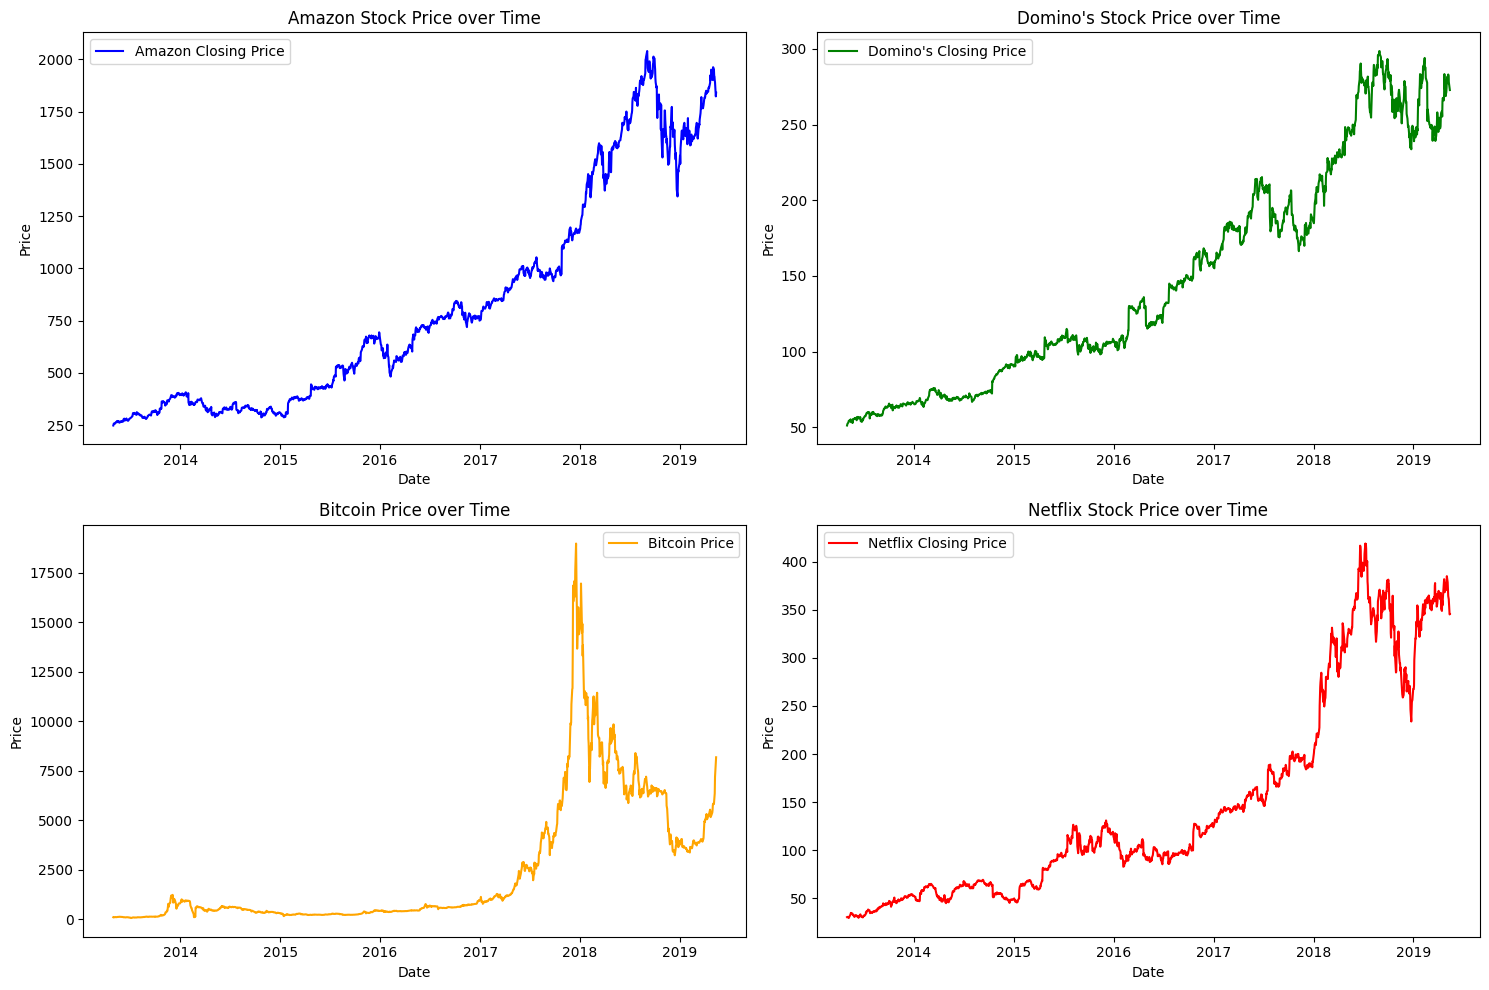

In [55]:
# Step 1: Convert 'date' column to datetime format (if not already done)
data['date'] = pd.to_datetime(data['date'])

# Step 2: Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,10))  # 2 rows, 2 columns

# Step 3: Plot Amazon (amzn)
axes[0, 0].plot(data['date'], data['amzn'], label='Amazon Closing Price', color='blue')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('Amazon Stock Price over Time')
axes[0, 0].legend()

# Step 4: Plot Domino's Pizza (dpz)
axes[0, 1].plot(data['date'], data['dpz'], label='Domino\'s Closing Price', color='green')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Price')
axes[0, 1].set_title('Domino\'s Stock Price over Time')
axes[0, 1].legend()

# Step 5: Plot Bitcoin (btc)
axes[1, 0].plot(data['date'], data['btc'], label='Bitcoin Price', color='orange')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('Bitcoin Price over Time')
axes[1, 0].legend()

# Step 6: Plot Netflix (nflx)
axes[1, 1].plot(data['date'], data['nflx'], label='Netflix Closing Price', color='red')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price')
axes[1, 1].set_title('Netflix Stock Price over Time')
axes[1, 1].legend()

# Step 7: Adjust layout and display
plt.tight_layout()  # Automatically adjust subplot parameters to give some padding
plt.show()


Feature engineering with technical indicators is a powerful way to enrich your stock price data, helping capture trends, momentum, and volatility that the raw prices alone might miss.

We'll calculate three commonly used technical indicators:

 Moving Averages (SMA): Captures the trend over a specific period.
 Relative Strength Index (RSI): Measures momentum.
 Bollinger Bands: Captures volatility around a moving average.

 Simple Moving Average (SMA): We compute a 50-day and a 200-day moving average for each stock.

50-day SMA: Captures short-term trends.
200-day SMA: Captures long-term trends.
Relative Strength Index (RSI): We compute a 14-day RSI for each stock. The RSI ranges from 0 to 100, with values above 70 indicating overbought conditions and values below 30 indicating oversold conditions.

Bollinger Bands: We calculate the 20-day Bollinger Bands for each stock. This consists of:

Middle Band (SMA): 20-day simple moving average.
Upper Band: 20-day SMA + (2 * standard deviation).
Lower Band: 20-day SMA - (2 * standard deviation).

In [56]:
# Fill missing values using forward fill
data.fillna(method='ffill', inplace=True)

In [57]:
# Step 1: Define functions for technical indicators

# Simple Moving Average (SMA)
def calculate_sma(data, window):
    return data.rolling(window=window).mean()

# Relative Strength Index (RSI)
def calculate_rsi(data, window=14):
    delta = data.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    RS = gain / loss
    return 100 - (100 / (1 + RS))

# Bollinger Bands (Middle Band, Upper Band, Lower Band)
def calculate_bollinger_bands(data, window=20):
    sma = data.rolling(window=window).mean()
    std = data.rolling(window=window).std()
    upper_band = sma + (std * 2)
    lower_band = sma - (std * 2)
    return sma, upper_band, lower_band

# Step 2: Apply these functions to each stock (AMZN, DPZ, BTC, NFLX)

# List of stocks to process
stocks = ['amzn', 'dpz', 'btc', 'nflx']

for stock in stocks:
    # Calculating 50-day and 200-day Simple Moving Averages (SMA)
    data[f'{stock}_SMA_50'] = calculate_sma(data[stock], 50)
    data[f'{stock}_SMA_200'] = calculate_sma(data[stock], 200)
    
    # Calculating 14-day RSI
    data[f'{stock}_RSI_14'] = calculate_rsi(data[stock], 14)
    
    # Calculating 20-day Bollinger Bands
    data[f'{stock}_BB_Mid'], data[f'{stock}_BB_Upper'], data[f'{stock}_BB_Lower'] = calculate_bollinger_bands(data[stock], 20)

# Step 3: Check the new columns in the dataframe
print(data[['date', 'amzn', 'amzn_SMA_50', 'amzn_SMA_200', 'amzn_RSI_14', 'amzn_BB_Mid', 'amzn_BB_Upper', 'amzn_BB_Lower']].tail())


           date         amzn  amzn_SMA_50  amzn_SMA_200  amzn_RSI_14  \
1515 2019-05-08  1917.770020  1804.152398   1753.569752    59.059034   
1516 2019-05-09  1899.869995  1809.327998   1754.059102    56.217842   
1517 2019-05-10  1889.979980  1814.330999   1754.362802    50.458293   
1518 2019-05-13  1822.680054  1817.350000   1754.158152    34.309135   
1519 2019-05-14  1840.119995  1820.228999   1754.318752    40.296013   

      amzn_BB_Mid  amzn_BB_Upper  amzn_BB_Lower  
1515  1898.183002    1976.337433    1820.028570  
1516  1900.810004    1975.209124    1826.410884  
1517  1903.105505    1972.818914    1833.392097  
1518  1902.086505    1975.966688    1828.206322  
1519  1901.849005    1976.529839    1827.168171  


## Outcome:
This will add the following columns for each stock:

SMA_50: 50-day Simple Moving Average.

SMA_200: 200-day Simple Moving Average.

RSI_14: 14-day Relative Strength Index.

BB_Mid, BB_Upper, BB_Lower: 20-day Bollinger Bands (Middle Band, Upper Band, Lower Band).

##### Why are we doing this?

SMA smooths the price data, helping to identify trends.

RSI provides momentum-based signals, identifying potential overbought or oversold conditions.

Bollinger Bands give insights into price volatility and potential price reversals.

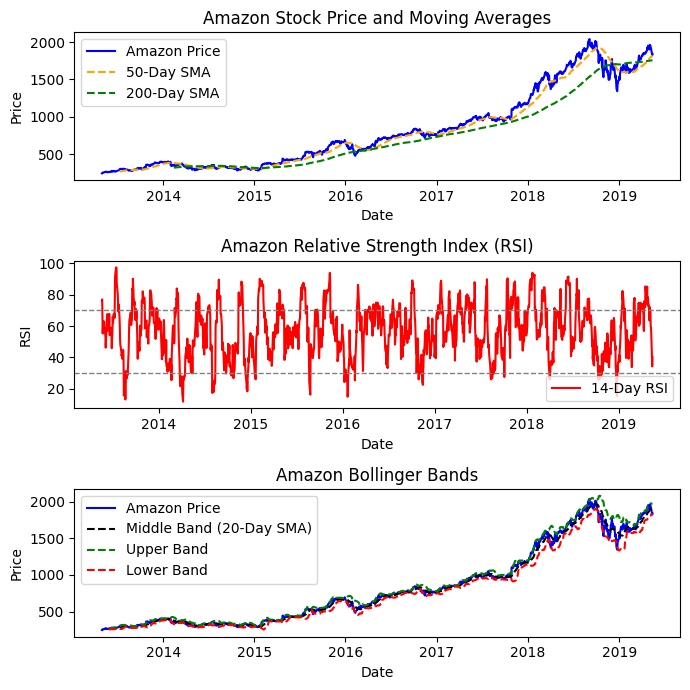

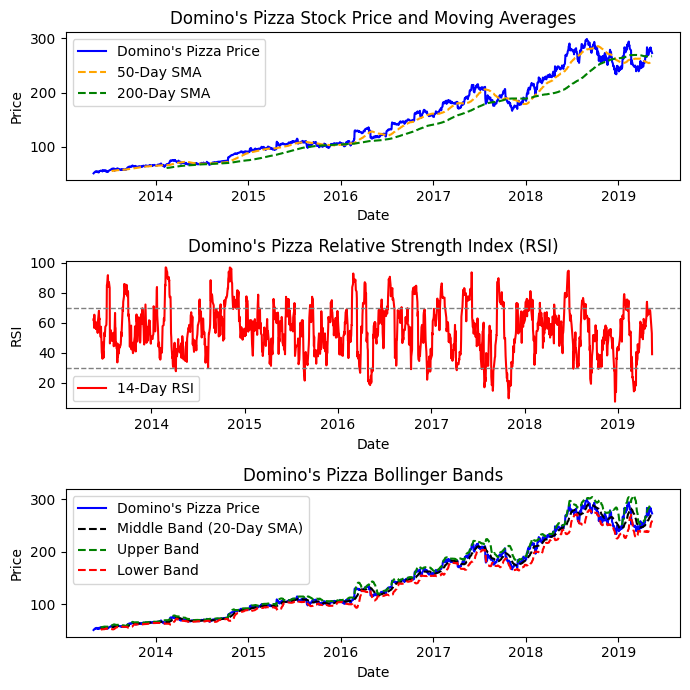

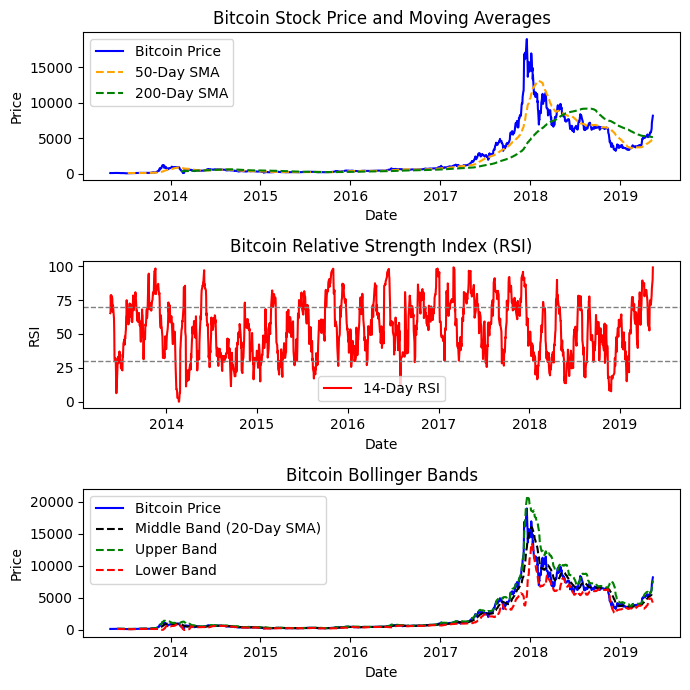

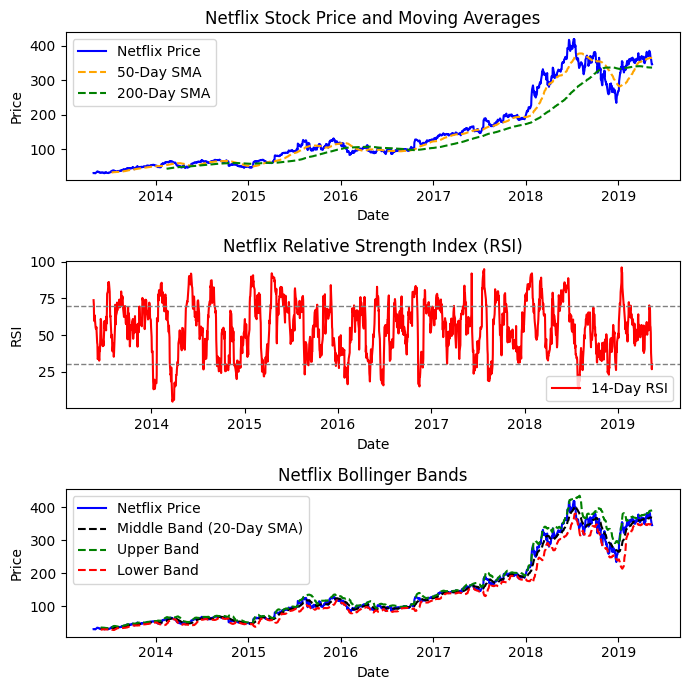

In [58]:
# List of stocks and their names for labeling
stocks = {'amzn': 'Amazon', 'dpz': 'Domino\'s Pizza', 'btc': 'Bitcoin', 'nflx': 'Netflix'}

# Create subplots for each stock
for stock, name in stocks.items():
    # Set up a figure for each stock with 3 subplots
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 7))
    
    # --- Plot 1: Stock Price and SMAs ---
    axes[0].plot(data['date'], data[stock], label=f'{name} Price', color='blue')
    axes[0].plot(data['date'], data[f'{stock}_SMA_50'], label='50-Day SMA', color='orange', linestyle='--')
    axes[0].plot(data['date'], data[f'{stock}_SMA_200'], label='200-Day SMA', color='green', linestyle='--')
    axes[0].set_title(f'{name} Stock Price and Moving Averages')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Price')
    axes[0].legend(loc='best')
    
    # --- Plot 2: RSI ---
    axes[1].plot(data['date'], data[f'{stock}_RSI_14'], label='14-Day RSI', color='red')
    axes[1].axhline(70, color='gray', linestyle='--', linewidth=1)  # Overbought level
    axes[1].axhline(30, color='gray', linestyle='--', linewidth=1)  # Oversold level
    axes[1].set_title(f'{name} Relative Strength Index (RSI)')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('RSI')
    axes[1].legend(loc='best')

    # --- Plot 3: Bollinger Bands ---
    axes[2].plot(data['date'], data[stock], label=f'{name} Price', color='blue')
    axes[2].plot(data['date'], data[f'{stock}_BB_Mid'], label='Middle Band (20-Day SMA)', color='black', linestyle='--')
    axes[2].plot(data['date'], data[f'{stock}_BB_Upper'], label='Upper Band', color='green', linestyle='--')
    axes[2].plot(data['date'], data[f'{stock}_BB_Lower'], label='Lower Band', color='red', linestyle='--')
    axes[2].set_title(f'{name} Bollinger Bands')
    axes[2].set_xlabel('Date')
    axes[2].set_ylabel('Price')
    axes[2].legend(loc='best')

    # Adjust layout for clarity
    plt.tight_layout()

    # Display the plot
    plt.show()


Subplot 1: Stock Price and SMAs: The stock price is plotted alongside the 50-day and 200-day SMAs to show short-term and long-term trends.

Subplot 2: RSI: The 14-day RSI is plotted, and reference lines at 70 (overbought) and 30 (oversold) are added to help interpret the RSI values.

Subplot 3: Bollinger Bands: The 20-day Bollinger Bands are plotted along with the stock price to show volatility.

Each stock will have its own figure, making it easier to view and interpret the results without clutter.

Visual Interpretation:

SMA: The short-term SMA (50-day) should track the price more closely than the long-term SMA (200-day). When the short-term SMA crosses above the long-term SMA, it’s often a bullish signal, and when it crosses below, it’s a bearish signal.

RSI: The RSI values above 70 indicate the stock is potentially overbought, while values below 30 indicate it might be oversold. This helps identify potential buying or selling points.

Bollinger Bands: The price often fluctuates within the upper and lower bands. If the price moves close to or beyond the bands, it suggests high volatility and potential price reversals.

## Data Splitting and Scaling

Data Splitting: We typically split the dataset into training and testing subsets. This helps evaluate the model's performance on unseen data, preventing overfitting.

Scaling: Most regression models, especially those based on distance (like Linear Regression and Random Forest), benefit from feature scaling. This is because features with larger ranges can disproportionately influence the model.

Prepare the Dataset:

We create a list of feature columns that include the historical stock prices and technical indicators for Amazon (AMZN), Domino's Pizza (DPZ), Bitcoin (BTC), and Netflix (NFLX).

The target variables (next_amzn, next_dpz, next_btc, next_nflx) represent the next day's closing prices for each stock, created by shifting the current prices up by one day.
Data Splitting:

We use train_test_split from sklearn to split the dataset into training (80%) and testing (20%) sets. The shuffle=False option preserves the time order of the data.
Feature Scaling:

We initialize a StandardScaler and fit it to the training data to scale the features to a mean of 0 and a standard deviation of 1.

The same scaler is then used to transform the test data to ensure consistency.

Check Shapes:

Finally, we print the shapes of the training and testing datasets to confirm the split was successful.

In [59]:
# Step 1: Prepare the dataset
# For this example, we'll focus on predicting the next day's closing price
# Create a new DataFrame for features (X) and target variable (Y)
feature_columns = ['amzn', 'amzn_SMA_50', 'amzn_SMA_200', 'amzn_RSI_14', 'amzn_BB_Mid', 
                   'dpz', 'dpz_SMA_50', 'dpz_SMA_200', 'dpz_RSI_14', 'dpz_BB_Mid', 
                   'btc', 'btc_SMA_50', 'btc_SMA_200', 'btc_RSI_14', 'btc_BB_Mid', 
                   'nflx', 'nflx_SMA_50', 'nflx_SMA_200', 'nflx_RSI_14', 'nflx_BB_Mid']

# Create the target variable (next day's closing price)
data['next_amzn'] = data['amzn'].shift(-1)
data['next_dpz'] = data['dpz'].shift(-1)
data['next_btc'] = data['btc'].shift(-1)
data['next_nflx'] = data['nflx'].shift(-1)

# Dropping rows with NaN values that were created by shifting
data.dropna(inplace=True)

# Define features (X) and target (Y)
X = data[feature_columns]
y = data[['next_amzn', 'next_dpz', 'next_btc', 'next_nflx']]  # Multiple target variables

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Step 3: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check the shapes of the resulting datasets
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")


X_train shape: (1056, 20), X_test shape: (264, 20)
y_train shape: (1056, 4), y_test shape: (264, 4)


Outcome:

After running this code, you'll have scaled feature matrices for training (X_train_scaled) and testing (X_test_scaled), along with corresponding target matrices (y_train, y_test) for all four stocks.

1. Linear Regression

    Linear Regression is a simple yet effective model that we can use for our regression task.

In [60]:
# Initialize Linear Regression model
lin_reg = LinearRegression()

# Fit the model for each stock and evaluate
for stock in ['next_amzn', 'next_dpz', 'next_btc', 'next_nflx']:
    # Train the model
    lin_reg.fit(X_train_scaled, y_train[stock])
    
    # Predict on the test set
    y_pred = lin_reg.predict(X_test_scaled)
    
    # Evaluate the model
    mse = np.mean((y_test[stock] - y_pred) ** 2)
    r2 = r2_score(y_test[stock], y_pred)
    
    print(f"{stock}: Linear Regression - MSE: {mse:.2f}, R^2: {r2:.2f}")


next_amzn: Linear Regression - MSE: 1381.32, R^2: 0.93
next_dpz: Linear Regression - MSE: 25.12, R^2: 0.91
next_btc: Linear Regression - MSE: 184309.39, R^2: 0.93
next_nflx: Linear Regression - MSE: 101.49, R^2: 0.93


2. Random Forest Regressor
        
    Random Forest is an ensemble method that can handle non-linear relationships and interactions between features effectively.

In [61]:
from sklearn.ensemble import RandomForestRegressor

# Initialize Random Forest Regressor model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model for each stock and evaluate
for stock in ['next_amzn', 'next_dpz', 'next_btc', 'next_nflx']:
    # Train the model
    rf_reg.fit(X_train_scaled, y_train[stock])
    
    # Predict on the test set
    y_pred = rf_reg.predict(X_test_scaled)
    
    # Evaluate the model
    mse = np.mean((y_test[stock] - y_pred) ** 2)
    r2 = r2_score(y_test[stock], y_pred)
    
    print(f"{stock}: Random Forest - MSE: {mse:.2f}, R^2: {r2:.2f}")


next_amzn: Random Forest - MSE: 98834.00, R^2: -3.99
next_dpz: Random Forest - MSE: 1200.84, R^2: -3.47
next_btc: Random Forest - MSE: 1918811.87, R^2: 0.28
next_nflx: Random Forest - MSE: 1564.52, R^2: -0.14


3. Long Short-Term Memory (LSTM)

    LSTMs are well-suited for time series forecasting. They can capture complex patterns over time, but they require careful tuning and are generally more complex than the other two.

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

In [ ]:
# Function to reshape the data for LSTM
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Reshape the training and testing data for LSTM
X_train_lstm, y_train_lstm = create_dataset(X_train_scaled, y_train.values, time_steps=1)
X_test_lstm, y_test_lstm = create_dataset(X_test_scaled, y_test.values, time_steps=1)

# Reshape for LSTM input
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], X_train_lstm.shape[2]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], X_test_lstm.shape[2]))

# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(50))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(4))  # Output layer for 4 stocks

# Compile and fit the LSTM model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32)

# Predict and evaluate LSTM model
y_pred_lstm = lstm_model.predict(X_test_lstm)

# Evaluate LSTM model
for i, stock in enumerate(['next_amzn', 'next_dpz', 'next_btc', 'next_nflx']):
    mse = np.mean((y_test.iloc[-len(y_pred_lstm):, i] - y_pred_lstm[:, i]) ** 2)
    r2 = r2_score(y_test.iloc[-len(y_pred_lstm):, i], y_pred_lstm[:, i])
    print(f"{stock}: LSTM - MSE: {mse:.2f}, R^2: {r2:.2f}")
